<a href="https://colab.research.google.com/github/K-Tanaka8/prophet_demand_forecast/blob/main/prophet_demand_forecast_sample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
'''
#  簡易需要予測サンプル (Prophet + 回帰変数)
このノートブックは、Google Colab上で動作する「Prophetによる簡易需要予測」のサンプルです。

- ダミーデータで動作確認済み
- 祝日・月末・ラグ変数を回帰として追加
- 未来予測と簡易在庫目安を可視化
- Google Colabでそのまま動かせます
- このリポジトリのコードはポートフォリオ用です。 閲覧は自由ですが、商用利用・再配布は不可です。
'''


'\n#  簡易需要予測サンプル (Prophet + 回帰変数)\nこのノートブックは、Google Colab上で動作する「Prophetによる簡易需要予測」のサンプルです。\n\n- ダミーデータで動作確認済み\n- 祝日・月末・ラグ変数を回帰として追加\n- 未来予測と簡易在庫目安を可視化\n- GitHubポートフォリオとして提示用\n'

In [2]:
# 1️ ライブラリ & フォント設定
!apt-get -q install fonts-ipafont-gothic -y
!fc-cache -fv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
import holidays
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/opentype/ipafont-gothic/ipagp.ttf"
fp = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = fp.get_name()
plt.rcParams['axes.unicode_minus'] = False

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  fonts-ipafont-mincho
The following NEW packages will be installed:
  fonts-ipafont-gothic fonts-ipafont-mincho
0 upgraded, 2 newly installed, 0 to remove and 2 not upgraded.
Need to get 8,237 kB of archives.
After this operation, 28.7 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-ipafont-gothic all 00303-21ubuntu1 [3,513 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-ipafont-mincho all 00303-21ubuntu1 [4,724 kB]
Fetched 8,237 kB in 2s (4,693 kB/s)
Selecting previously unselected package fonts-ipafont-gothic.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../fonts-ipafont-gothic_00303-21ubuntu1_all.deb ...
Unpacking fonts-ipafont-gothic (00303-21ubuntu1) ...
Selecting previously unselected package fonts-ipafont-mincho.
Pre

In [3]:
# 2️ ダミーデータ作成
np.random.seed(42)
dates = pd.date_range("2024-01-01", periods=180)
sales = np.random.poisson(50, len(dates)) + np.random.randint(-5,5,len(dates))

df = pd.DataFrame({"ds":dates, "y":sales})

In [4]:
# 3️ 特徴量追加
JP_HOLIDAYS = holidays.Japan(years=[2024])

df["祝日"] = df["ds"].isin(JP_HOLIDAYS).astype(int)
df["月末"] = df["ds"].dt.is_month_end.astype(int)
df["y_lag_7"] = df["y"].shift(7)
df["y_lag_7"].fillna(df["y"].mean(), inplace=True)

/tmp/ipykernel_1692/3607342807.py:4: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df["祝日"] = df["ds"].isin(JP_HOLIDAYS).astype(int)
/tmp/ipykernel_1692/3607342807.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["y_lag_7"].fillna(df["y"].mean(), inplace=True)


In [5]:
# 4️ Prophetモデル構築 & 学習
m = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.1
)
m.add_regressor("祝日")
m.add_regressor("月末")
m.add_regressor("y_lag_7")

train_df = df[["ds","y","祝日","月末","y_lag_7"]]
m.fit(train_df)

In [6]:
# 5️ 未来予測
future = m.make_future_dataframe(periods=14)
future["祝日"] = future["ds"].isin(JP_HOLIDAYS).astype(int)
future["月末"] = future["ds"].dt.is_month_end.astype(int)
future["y_lag_7"] = future["ds"].map(df.set_index("ds")["y_lag_7"]).fillna(df["y"].mean())

forecast = m.predict(future)
forecast["buffered_reference"] = np.ceil(forecast["yhat_upper"])

/tmp/ipykernel_1692/2760564238.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  future["祝日"] = future["ds"].isin(JP_HOLIDAYS).astype(int)


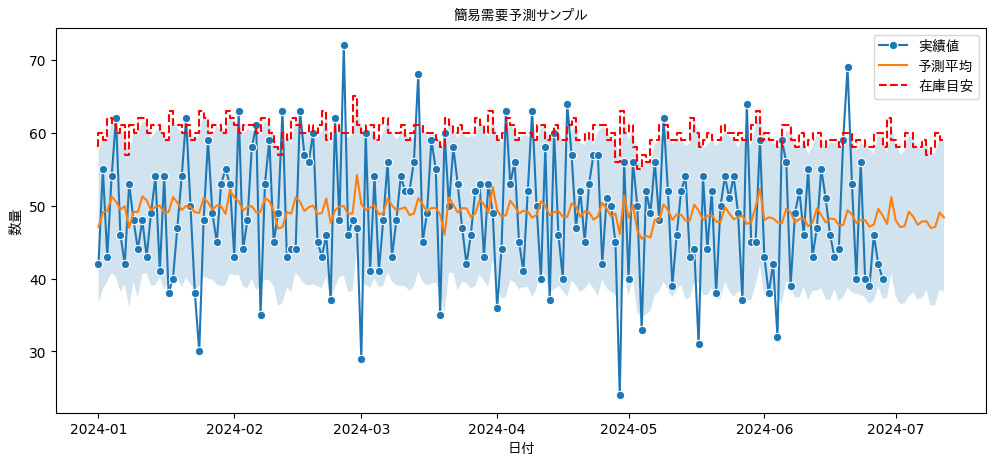

In [7]:
# 6️ 可視化
fig, ax = plt.subplots(figsize=(12,5))
sns.lineplot(x="ds", y="y", data=df, label="実績値", marker="o", ax=ax)
sns.lineplot(x="ds", y="yhat", data=forecast, label="予測平均", ax=ax)
ax.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"], alpha=0.2)
ax.step(forecast["ds"], forecast["buffered_reference"], label="在庫目安", color="red", linestyle="--")
ax.set_title("簡易需要予測サンプル", fontproperties=fp)
ax.set_xlabel("日付", fontproperties=fp)
ax.set_ylabel("数量", fontproperties=fp)
ax.legend(prop=fp)
plt.show()